In [1]:
pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

embedder = SentenceTransformer("all-MiniLM-L6-v2")

In [14]:
import pandas as pd
df = pd.read_csv("d:\Hallucination Calibration In LLM's\databases\merged_with_truthfulqa.csv")
print(df.columns)

Index(['id', 'question_id', 'question', 'answer', 'model_name', 'band',
       'generation_index', 'temperature', 'top_p', 'mean_entropy',
       'max_entropy', 'early_entropy', 'entropy_variance', 'mean_logprob',
       'min_logprob', 'logprob_variance', 'sequence_loglikelihood',
       'answer_length_tokens', 'answer_length_chars', 'generation_time',
       'created_at', 'Correct Answers', 'Incorrect Answers'],
      dtype='object')


<>:2: SyntaxWarning: invalid escape sequence '\H'
<>:2: SyntaxWarning: invalid escape sequence '\H'
C:\Users\hp\AppData\Local\Temp\ipykernel_23232\3791574477.py:2: SyntaxWarning: invalid escape sequence '\H'
  df = pd.read_csv("d:\Hallucination Calibration In LLM's\databases\merged_with_truthfulqa.csv")


In [15]:
def cosine_label(row):

    answer = str(row["answer"])[:300]

    correct = str(row["Correct Answers"]).split(";")
    incorrect = str(row["Incorrect Answers"]).split(";")

    ans_emb = embedder.encode([answer])
    cor_emb = embedder.encode(correct)
    inc_emb = embedder.encode(incorrect)

    sim_correct = cosine_similarity(ans_emb, cor_emb).max()
    sim_incorrect = cosine_similarity(ans_emb, inc_emb).max()

    margin = sim_correct - sim_incorrect

    label = 1 if margin > 0.05 else 0

    return pd.Series([sim_correct, sim_incorrect, margin, label])

In [16]:
df[
    ["cos_sim_correct",
     "cos_sim_incorrect",
     "cos_margin",
     "label_cosine"]
] = df.apply(cosine_label, axis=1)

c:\Users\hp\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\hp\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\hp\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\hp\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\hp\anaconda3\Lib\site-packa

In [17]:
print("Cosine correctness rate:")
print(df["label_cosine"].mean())

print("\nPer-model correctness:")
print(df.groupby("model_name")["label_cosine"].mean())

Cosine correctness rate:
0.25125

Per-model correctness:
model_name
TinyLlama/TinyLlama-1.1B-Chat-v1.0    0.1875
meta-llama/Llama-2-7b-chat-hf         0.2475
meta-llama/Llama-3.2-1B-Instruct      0.2175
meta-llama/Llama-3.2-3B-Instruct      0.2500
microsoft/Phi-3-mini-4k-instruct      0.3050
mistralai/Mistral-7B-Instruct-v0.2    0.3000
Name: label_cosine, dtype: float64


In [18]:
df.to_csv(
r"D:\Hallucination Calibration In LLM's\databases\cosine_labeled_dataset.csv",
index=False
)

print("Cosine labeled dataset saved.")

Cosine labeled dataset saved.


In [19]:
import pandas as pd

df = pd.read_csv(
r"D:\Hallucination Calibration In LLM's\databases\cosine_labeled_dataset.csv"
)

print("Total rows:", len(df))

print("\nLabel distribution:")
print(df["label_cosine"].value_counts())

print("\nLabel percentages:")
print(df["label_cosine"].value_counts(normalize=True))

Total rows: 2400

Label distribution:
label_cosine
0.0    1797
1.0     603
Name: count, dtype: int64

Label percentages:
label_cosine
0.0    0.74875
1.0    0.25125
Name: proportion, dtype: float64


In [21]:
print(df.groupby("model_name")["label_cosine"].mean())

model_name
TinyLlama/TinyLlama-1.1B-Chat-v1.0    0.1875
meta-llama/Llama-2-7b-chat-hf         0.2475
meta-llama/Llama-3.2-1B-Instruct      0.2175
meta-llama/Llama-3.2-3B-Instruct      0.2500
microsoft/Phi-3-mini-4k-instruct      0.3050
mistralai/Mistral-7B-Instruct-v0.2    0.3000
Name: label_cosine, dtype: float64


In [22]:
df["cos_margin"].describe()

count    2400.000000
mean       -0.021154
std         0.163499
min        -0.923092
25%        -0.076493
50%        -0.003798
75%         0.050093
max         0.694101
Name: cos_margin, dtype: float64

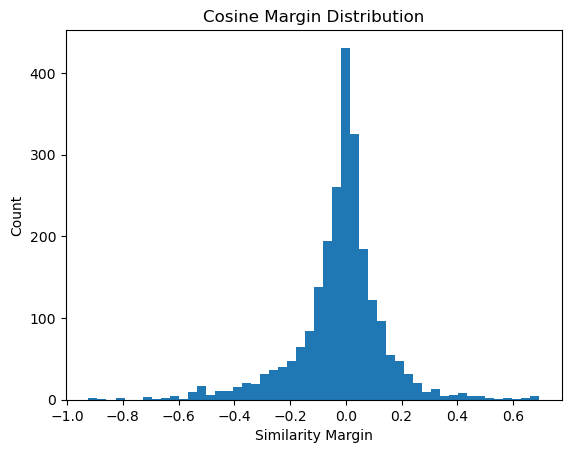

In [23]:
import matplotlib.pyplot as plt

plt.hist(df["cos_margin"], bins=50)
plt.title("Cosine Margin Distribution")
plt.xlabel("Similarity Margin")
plt.ylabel("Count")
plt.show()

In [24]:
df["mean_entropy"].describe()

count    2400.000000
mean        0.394359
std         0.258377
min         0.000000
25%         0.201831
50%         0.359266
75%         0.563740
max         1.732503
Name: mean_entropy, dtype: float64

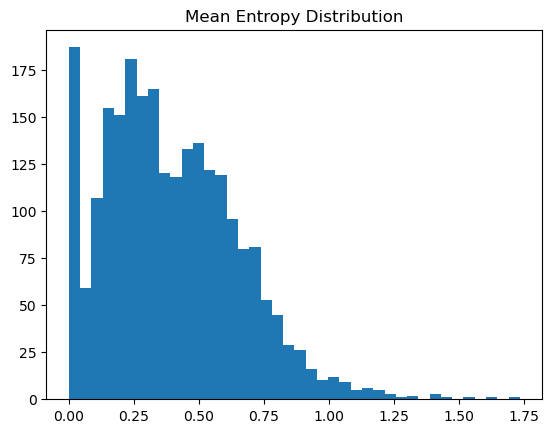

In [25]:
plt.hist(df["mean_entropy"], bins=40)
plt.title("Mean Entropy Distribution")
plt.show()

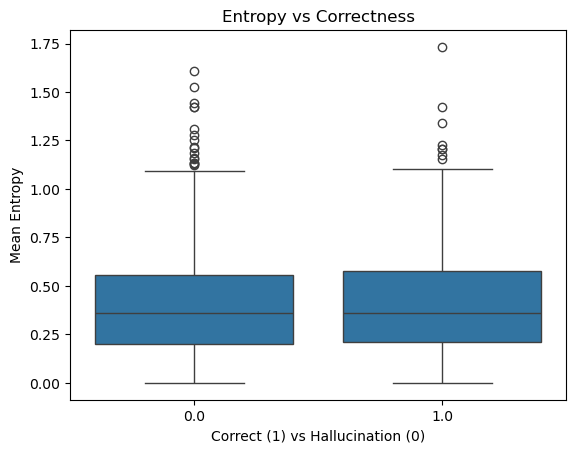

In [26]:
import seaborn as sns

sns.boxplot(x="label_cosine", y="mean_entropy", data=df)

plt.title("Entropy vs Correctness")
plt.xlabel("Correct (1) vs Hallucination (0)")
plt.ylabel("Mean Entropy")

plt.show()

In [27]:
df["label_cosine"].value_counts(normalize=True)

df.groupby("model_name")["label_cosine"].mean()

df["cos_margin"].describe()

df.groupby("label_cosine")["mean_entropy"].mean()

label_cosine
0.0    0.389544
1.0    0.408710
Name: mean_entropy, dtype: float64